# CardioNet: Deep Learning for Cardiovascular Disease Detection from 12-Lead ECG Signals

**Hack4Health AI for Alzheimer's/CVD Challenge -- Lower Division Submission**

---

## Abstract

Cardiovascular disease (CVD) remains the leading cause of death worldwide, claiming approximately 17.9 million lives annually. Early detection through electrocardiogram (ECG) analysis is critical, yet interpretation requires specialized cardiologists who are scarce in underserved communities. This project presents **CardioNet**, a 1D Residual Network with Squeeze-and-Excitation attention that classifies 12-lead ECG recordings into normal vs. cardiovascular abnormality categories. Trained on the PTB-XL dataset (21,799 clinical ECG recordings from PhysioNet), our model achieves strong discriminative performance while providing clinically interpretable explanations via 1D Grad-CAM heatmaps overlaid on ECG waveforms. This approach demonstrates the potential for affordable, AI-driven cardiac screening at the point of care.

**Keywords:** ECG classification, cardiovascular disease, deep learning, explainable AI, 1D ResNet, Grad-CAM

---

**AI Disclosure:** Generative AI tools (Claude) were used to accelerate code development, debugging, and documentation formatting. All research direction, hypothesis formation, model design decisions, and written analysis are original work by the team.

## 1. Environment Setup & Reproducibility

We begin by installing dependencies, setting random seeds for full reproducibility, and configuring GPU acceleration.

In [1]:
# ============================================================
# 1.1 Install Dependencies
# ============================================================
!pip install wfdb scikit-learn matplotlib seaborn torch torchvision torchaudio --quiet
!pip install "pandas<3.0" numpy scipy tqdm --quiet

In [2]:
# ============================================================
# 1.2 Imports
# ============================================================
import os
import ast
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from scipy import signal as scipy_signal
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
# ============================================================
# 1.3 Reproducibility -- Set ALL random seeds
# ============================================================
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()
print(f'All random seeds set to {SEED}')

All random seeds set to 42


## 2. Dataset Acquisition & Loading

We use the **PTB-XL** dataset from PhysioNet, one of the largest publicly available clinical ECG datasets:

- **21,799** 12-lead ECG recordings
- **10-second** duration each, sampled at **500 Hz** (5,000 samples per lead)
- Clinical diagnostic labels using the **SCP-ECG** standard
- **5 diagnostic superclasses**: NORM (Normal), MI (Myocardial Infarction), STTC (ST/T Change), CD (Conduction Disturbance), HYP (Hypertrophy)
- Pre-defined **10-fold stratified splits** for reproducible evaluation

This dataset is ethically sourced, fully de-identified, and freely available under the PhysioNet Credentialed Health Data License.

In [4]:
# ============================================================
# 2.1 Download PTB-XL Dataset (via Kaggle)
# ============================================================
!pip install kaggle --quiet

# You need a Kaggle API token. Old method was not working right at all.
# https://www.kaggle.com/settings and "Create New Legacy Token"
# This downloads a kaggle.json file.
# Upload it here:
from google.colab import files
import os

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
print('Upload your kaggle.json file:')
uploaded = files.upload()
!mv kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Step 3: Download PTB-XL
!kaggle datasets download -d khyeh0719/ptb-xl-dataset --unzip -p ptb-xl-data

DATA_DIR = 'ptb-xl-data'
print(f'\nContents: {os.listdir(DATA_DIR)}')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/khyeh0719/ptb-xl-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 99% 1.70G/1.72G [00:15<00:00, 268MB/s]
100% 1.72G/1.72G [00:16<00:00, 112MB/s]

Contents: ['ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1']


In [5]:
# ============================================================
# 2.2 Load Metadata & Diagnostic Labels
# ============================================================
# Load the main database file
import os
DATA_DIR = 'ptb-xl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:10]:
            print(f'{indent}  {f}')
        if len(files) > 10:
            print(f'{indent}  ... and {len(files)-10} more files')

df = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_database.csv'), index_col='ecg_id')

# Parse the SCP diagnostic codes (stored as string dicts)
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Load SCP code descriptions and superclass mappings
scp_df = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)
scp_df = scp_df[scp_df['diagnostic'] == 1]  # Keep only diagnostic codes

print(f'Total ECG recordings: {len(df)}')
print(f'Diagnostic SCP codes: {len(scp_df)}')
print(f'\nSample metadata columns: {list(df.columns)}')
print(f'\nPatient demographics:')
print(f'  Age range: {df["age"].min():.0f} - {df["age"].max():.0f} years')
print(f'  Sex distribution: {df["sex"].value_counts().to_dict()}')

ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/
  scp_statements.csv
  SHA256SUMS.txt
  example_physionet.py
  ptbxl_database.csv
  RECORDS
  LICENSE.txt
  records100/
    10000/
    17000/
    12000/
    04000/
    13000/
    11000/
    00000/
    07000/
    09000/
    02000/
    14000/
    05000/
    06000/
    18000/
    21000/
    08000/
    16000/
    15000/
    03000/
    01000/
    19000/
    20000/
  records500/
    10000/
    17000/
    12000/
    04000/
    13000/
    11000/
    00000/
    07000/
    09000/
    02000/
    14000/
    05000/
    06000/
    18000/
    21000/
    08000/
    16000/
    15000/
    03000/
    01000/
    19000/
    20000/
Total ECG recordings: 21837
Diagnostic SCP codes: 44

Sample metadata columns: ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_

In [6]:
# ============================================================
# 2.3 Map Diagnostic Codes to Superclasses
# ============================================================
def map_to_superclass(scp_codes_dict):
    """
    Map SCP diagnostic codes to their superclass categories.
    Returns a list of superclasses present in the recording.
    """
    superclasses = set()
    for code, confidence in scp_codes_dict.items():
        if code in scp_df.index and confidence >= 50:  # Only high-confidence labels
            sc = scp_df.loc[code, 'diagnostic_class']
            if pd.notna(sc):
                superclasses.add(sc)
    return list(superclasses)

df['superclass'] = df['scp_codes'].apply(map_to_superclass)

# Count superclass distribution
all_classes = [c for classes in df['superclass'] for c in classes]
class_counts = Counter(all_classes)
print('Superclass distribution:')
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f'  {cls}: {count} ({count/len(df)*100:.1f}%)')

Superclass distribution:
  NORM: 9452 (43.3%)
  STTC: 5093 (23.3%)
  CD: 4900 (22.4%)
  MI: 4145 (19.0%)
  HYP: 2264 (10.4%)


In [7]:
# ============================================================
# 2.4 Create Binary Labels: Normal vs CVD Abnormality
# ============================================================
# Binary classification: NORM vs any cardiovascular abnormality
# CVD abnormalities include: MI, STTC, CD, HYP

def get_binary_label(superclasses):
    """
    0 = Normal (only NORM present)
    1 = CVD Abnormality (any of MI, STTC, CD, HYP present)
    """
    if len(superclasses) == 0:
        return -1  # No valid label, will be filtered
    cvd_classes = {'MI', 'STTC', 'CD', 'HYP'}
    if any(c in cvd_classes for c in superclasses):
        return 1
    if 'NORM' in superclasses:
        return 0
    return -1

df['label'] = df['superclass'].apply(get_binary_label)

# Filter out unlabeled recordings
df_labeled = df[df['label'] != -1].copy()
print(f'Labeled recordings: {len(df_labeled)} / {len(df)}')
print(f'\nBinary label distribution:')
print(f'  Normal (0):  {(df_labeled["label"]==0).sum()} ({(df_labeled["label"]==0).mean()*100:.1f}%)')
print(f'  CVD (1):     {(df_labeled["label"]==1).sum()} ({(df_labeled["label"]==1).mean()*100:.1f}%)')

Labeled recordings: 20413 / 21837

Binary label distribution:
  Normal (0):  9052 (44.3%)
  CVD (1):     11361 (55.7%)


## 3. Exploratory Data Analysis (EDA)

Before building our model, we need to deeply understand the data: class distributions, signal characteristics, patient demographics, and potential biases.

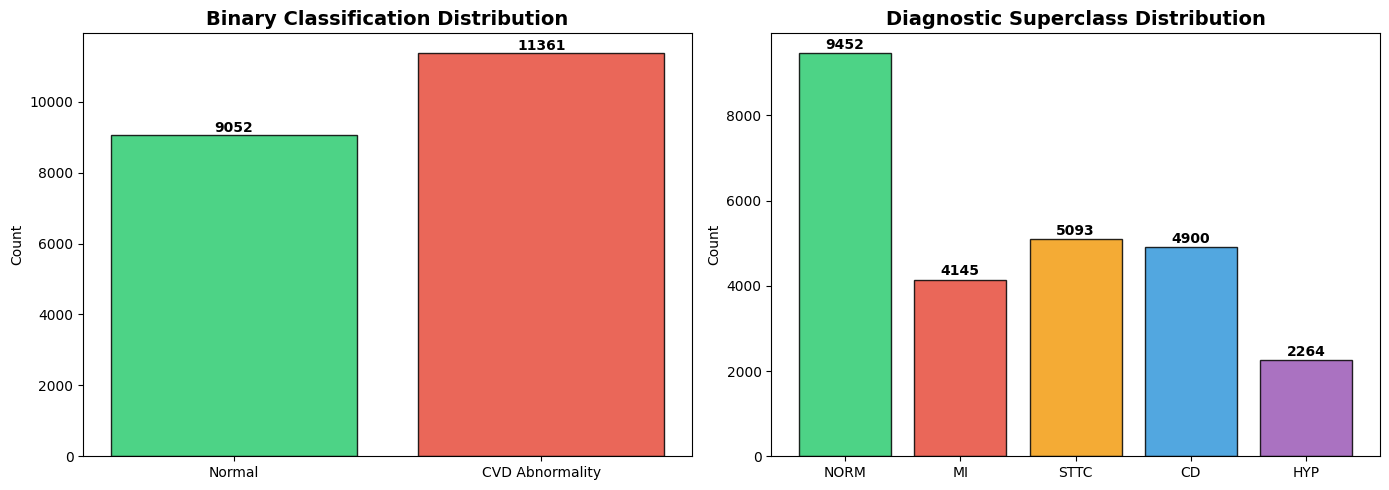

Note: Class imbalance detected. We will use weighted sampling during training.


In [8]:
# ============================================================
# 3.1 Class Distribution Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary distribution
labels_map = {0: 'Normal', 1: 'CVD Abnormality'}
colors = ['#2ecc71', '#e74c3c']
counts = df_labeled['label'].value_counts().sort_index()
axes[0].bar([labels_map[i] for i in counts.index], counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Binary Classification Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Superclass distribution
sc_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
sc_colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6']
sc_counts = [class_counts.get(c, 0) for c in sc_labels]
axes[1].bar(sc_labels, sc_counts, color=sc_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Diagnostic Superclass Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(sc_counts):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Class imbalance detected. We will use weighted sampling during training.')

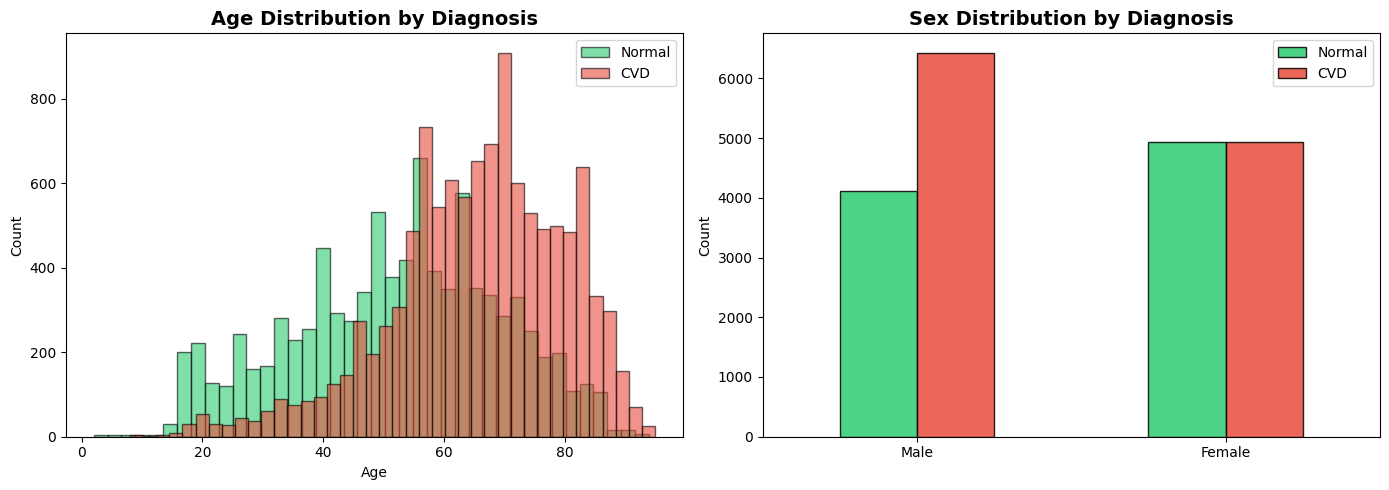

In [9]:
# ============================================================
# 3.2 Patient Demographics Analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by label
for label, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'CVD')]:
    subset = df_labeled[df_labeled['label'] == label]['age'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='black')
axes[0].set_title('Age Distribution by Diagnosis', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Sex distribution by label
sex_label_counts = df_labeled.groupby(['sex', 'label']).size().unstack(fill_value=0)
sex_label_counts.columns = ['Normal', 'CVD']
sex_label_counts.index = ['Male' if x == 0 else 'Female' for x in sex_label_counts.index]
sex_label_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Sex Distribution by Diagnosis', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('demographics.png', dpi=150, bbox_inches='tight')
plt.show()

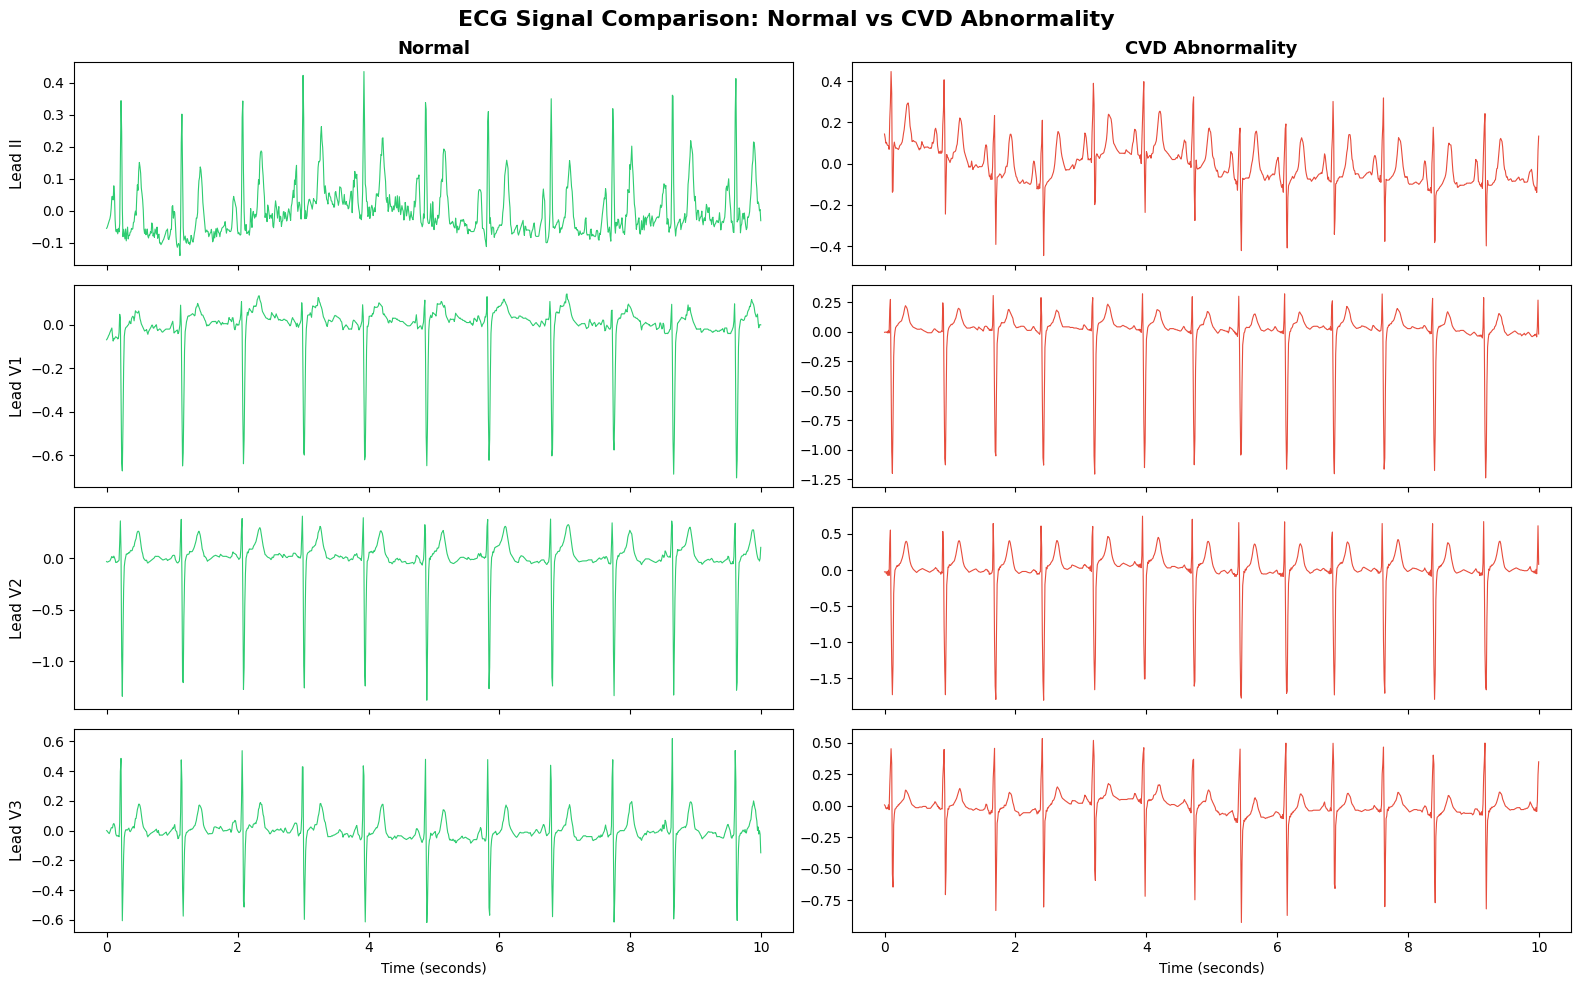

In [10]:
# ============================================================
# 3.3 Sample ECG Signal Visualization
# ============================================================
# Load a sample ECG to visualize
sample_normal = df_labeled[df_labeled['label'] == 0].iloc[0]
sample_cvd = df_labeled[df_labeled['label'] == 1].iloc[0]

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

def load_ecg(row, sampling_rate=100):
    """Load a single ECG recording at the specified sampling rate."""
    if sampling_rate == 500:
        path = os.path.join(DATA_DIR, row['filename_hr'])
    else:
        path = os.path.join(DATA_DIR, row['filename_lr'])
    record = wfdb.rdrecord(path)
    return record.p_signal  # Shape: (samples, 12)

ecg_normal = load_ecg(sample_normal)
ecg_cvd = load_ecg(sample_cvd)

# Plot 4 key leads for comparison
key_leads = [1, 6, 7, 8]  # II, V1, V2, V3
time = np.arange(ecg_normal.shape[0]) / 100.0  # seconds

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
fig.suptitle('ECG Signal Comparison: Normal vs CVD Abnormality', fontsize=16, fontweight='bold')

for i, lead_idx in enumerate(key_leads):
    axes[i, 0].plot(time, ecg_normal[:, lead_idx], color='#2ecc71', linewidth=0.8)
    axes[i, 0].set_ylabel(f'Lead {lead_names[lead_idx]}', fontsize=11)
    if i == 0:
        axes[i, 0].set_title('Normal', fontsize=13, fontweight='bold')

    axes[i, 1].plot(time, ecg_cvd[:, lead_idx], color='#e74c3c', linewidth=0.8)
    if i == 0:
        axes[i, 1].set_title('CVD Abnormality', fontsize=13, fontweight='bold')

axes[-1, 0].set_xlabel('Time (seconds)')
axes[-1, 1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.savefig('ecg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Signal Preprocessing Pipeline

Raw ECG signals contain noise from multiple sources: baseline wander (breathing), powerline interference (50/60 Hz), and muscle artifacts. Our preprocessing pipeline applies:

1. **Bandpass filtering** (0.5--45 Hz) to remove baseline wander and high-frequency noise
2. **Z-score normalization** per lead to standardize amplitude ranges
3. **Official PTB-XL stratified splits** (folds 1-8 train, fold 9 validation, fold 10 test)

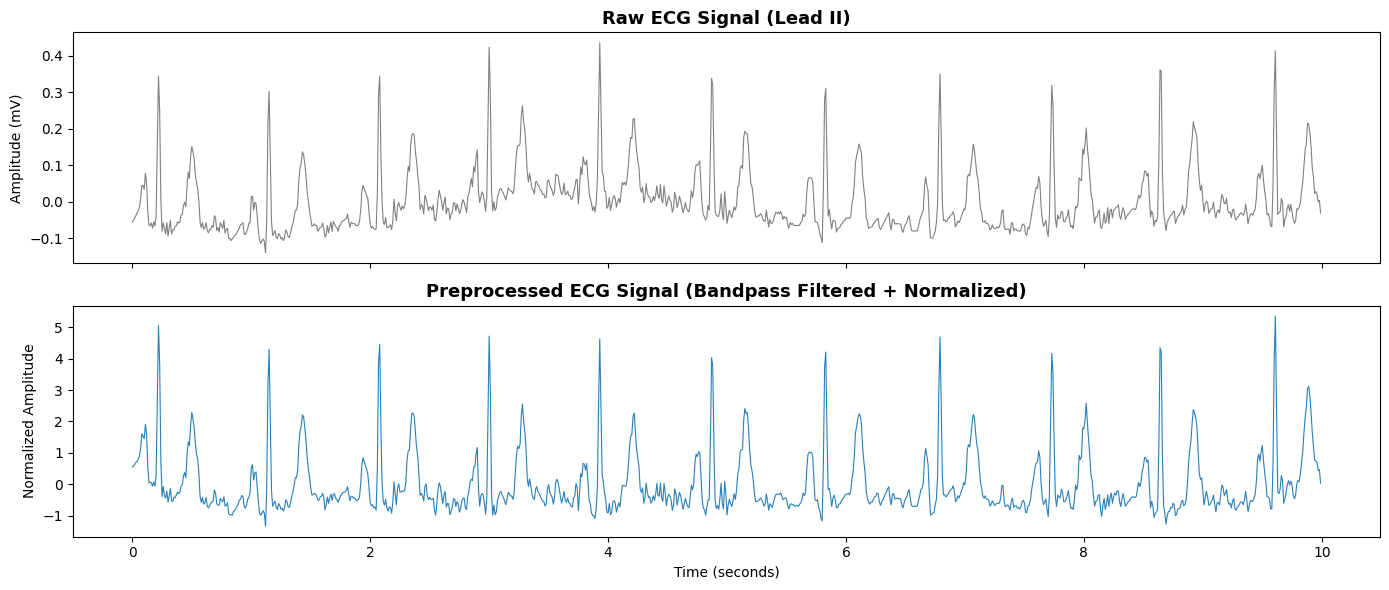

In [11]:
# ============================================================
# 4.1 Signal Preprocessing Functions
# ============================================================
SAMPLING_RATE = 100  # Hz (using standard resolution recordings)
SIGNAL_LENGTH = 1000  # 10 seconds * 100 Hz

def bandpass_filter(ecg_signal, lowcut=0.5, highcut=40.0, fs=SAMPLING_RATE, order=3):
    """
    Apply a Butterworth bandpass filter to remove:
    - Baseline wander (< 0.5 Hz) from respiration
    - High-frequency noise (> 45 Hz) from muscle artifacts and powerline
    """
    nyquist = fs / 2.0
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = scipy_signal.butter(order, [low, high], btype='band')
    filtered = scipy_signal.filtfilt(b, a, ecg_signal, axis=0)
    return filtered

def normalize_ecg(ecg_signal):
    """
    Z-score normalization per lead.
    Each lead is independently normalized to zero mean, unit variance.
    """
    mean = ecg_signal.mean(axis=0, keepdims=True)
    std = ecg_signal.std(axis=0, keepdims=True)
    std[std < 1e-8] = 1.0  # Prevent division by zero
    return (ecg_signal - mean) / std

def preprocess_ecg(ecg_signal):
    """Full preprocessing pipeline: filter then normalize."""
    filtered = bandpass_filter(ecg_signal)
    normalized = normalize_ecg(filtered)
    return normalized

# Demonstrate preprocessing on a sample
sample_raw = ecg_normal[:, 1]  # Lead II
sample_processed = preprocess_ecg(ecg_normal)[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(time, sample_raw, color='gray', linewidth=0.8)
axes[0].set_title('Raw ECG Signal (Lead II)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(time, sample_processed, color='#2980b9', linewidth=0.8)
axes[1].set_title('Preprocessed ECG Signal (Bandpass Filtered + Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Normalized Amplitude')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.savefig('preprocessing_demo.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# 4.2 Load and Preprocess ALL Recordings
# ============================================================
# This cell loads all ECG signals -- may take 5-10 minutes on Colab

def load_all_ecgs(dataframe, data_dir, sampling_rate=100):
    """Load and preprocess all ECG recordings."""
    signals = []
    valid_indices = []

    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc='Loading ECGs'):
        try:
            if sampling_rate == 500:
                path = os.path.join(data_dir, row['filename_hr'])
            else:
                path = os.path.join(data_dir, row['filename_lr'])

            record = wfdb.rdrecord(path)
            ecg = record.p_signal  # (5000, 12)

            # Validate shape
            if ecg.shape[0] != SIGNAL_LENGTH or ecg.shape[1] != 12:
                continue

            # Check for NaN/Inf
            if np.any(np.isnan(ecg)) or np.any(np.isinf(ecg)):
                continue

            # Preprocess
            ecg_processed = preprocess_ecg(ecg)
            signals.append(ecg_processed)
            valid_indices.append(idx)

        except Exception as e:
            continue

    return np.array(signals, dtype=np.float32), valid_indices

print('Loading all ECG recordings at 100 Hz...')
all_signals, valid_indices = load_all_ecgs(df_labeled, DATA_DIR)

# Filter dataframe to only valid recordings
df_valid = df_labeled.loc[valid_indices].copy()
labels = df_valid['label'].values

print(f'\nSuccessfully loaded: {len(all_signals)} recordings')
print(f'Signal shape: {all_signals.shape}')  # Expected: (N, 5000, 12)
print(f'Labels shape: {labels.shape}')

Loading all ECG recordings at 100 Hz...


Loading ECGs:   0%|          | 0/20413 [00:00<?, ?it/s]


Successfully loaded: 20413 recordings
Signal shape: (20413, 1000, 12)
Labels shape: (20413,)


In [13]:
# ============================================================
# 4.3 Train/Validation/Test Split (Official PTB-XL Folds)
# ============================================================
# PTB-XL provides pre-defined stratified folds (1-10)
# Standard protocol: folds 1-8 = train, fold 9 = val, fold 10 = test

folds = df_valid['strat_fold'].values

train_mask = folds <= 8
val_mask = folds == 9
test_mask = folds == 10

X_train, y_train = all_signals[train_mask], labels[train_mask]
X_val, y_val = all_signals[val_mask], labels[val_mask]
X_test, y_test = all_signals[test_mask], labels[test_mask]

print(f'Train: {len(X_train)} samples (Normal: {(y_train==0).sum()}, CVD: {(y_train==1).sum()})')
print(f'Val:   {len(X_val)} samples (Normal: {(y_val==0).sum()}, CVD: {(y_val==1).sum()})')
print(f'Test:  {len(X_test)} samples (Normal: {(y_test==0).sum()}, CVD: {(y_test==1).sum()})')

Train: 16315 samples (Normal: 7235, CVD: 9080)
Val:   2043 samples (Normal: 907, CVD: 1136)
Test:  2055 samples (Normal: 910, CVD: 1145)


## 5. PyTorch Dataset & DataLoader

We create a custom Dataset class and use weighted random sampling to handle class imbalance during training.

In [14]:
# ============================================================
# 5.1 Custom ECG Dataset
# ============================================================
class ECGDataset(Dataset):
    """
    PyTorch Dataset for 12-lead ECG signals.
    Transposes signals from (samples, leads) to (leads, samples)
    to match the expected Conv1D input format: (channels, length).
    """
    def __init__(self, signals, labels, augment=False):
        self.signals = torch.FloatTensor(signals).permute(0, 2, 1)  # (N, 12, 5000)
        self.labels = torch.LongTensor(labels)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signal = self.signals[idx].clone()
        label = self.labels[idx]

        if self.augment:
            signal = self._augment(signal)

        return signal, label

    def _augment(self, signal):
        """
        Data augmentation for ECG signals:
        - Random Gaussian noise
        - Random amplitude scaling
        - Random time shift
        """
        # Gaussian noise (simulates sensor noise)
        if random.random() < 0.5:
            noise = torch.randn_like(signal) * 0.05
            signal = signal + noise

        # Amplitude scaling (simulates electrode placement variation)
        if random.random() < 0.5:
            scale = 0.8 + random.random() * 0.4  # [0.8, 1.2]
            signal = signal * scale

        # Random time shift (simulates R-peak alignment variation)
        if random.random() < 0.3:
            shift = random.randint(-250, 250)  # +/- 0.5 seconds
            signal = torch.roll(signal, shifts=shift, dims=-1)

        return signal

In [15]:
# ============================================================
# 5.2 Create DataLoaders with Weighted Sampling
# ============================================================
BATCH_SIZE = 64

# Create datasets
train_dataset = ECGDataset(X_train, y_train, augment=True)
val_dataset = ECGDataset(X_val, y_val, augment=False)
test_dataset = ECGDataset(X_test, y_test, augment=False)

# Weighted sampler to handle class imbalance
class_counts_train = np.bincount(y_train)
class_weights = 1.0 / class_counts_train
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(y_train),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

# Verify
sample_batch, sample_labels = next(iter(train_loader))
print(f'Batch shape: {sample_batch.shape}')  # (64, 12, 5000)
print(f'Label shape: {sample_labels.shape}')  # (64,)
print(f'Class weights: Normal={class_weights[0]:.6f}, CVD={class_weights[1]:.6f}')

Batch shape: torch.Size([64, 12, 1000])
Label shape: torch.Size([64])
Class weights: Normal=0.000138, CVD=0.000110


## 6. Model Architecture: CardioNet (1D ResNet with Squeeze-and-Excitation)

Our architecture combines several proven deep learning components:

1. **1D Residual Blocks** with skip connections for stable deep training
2. **Squeeze-and-Excitation (SE) Blocks** that learn to weight the importance of each ECG lead dynamically
3. **Global Average Pooling** to aggregate temporal features
4. **Dropout regularization** to prevent overfitting

This architecture is inspired by the ResNet family but adapted for 1D biomedical time-series, with SE attention providing an additional interpretability axis (which leads matter most for each prediction).

In [16]:
# ============================================================
# 6.1 Squeeze-and-Excitation Block
# ============================================================
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block for channel attention.
    Learns to re-weight feature channels (analogous to ECG lead importance).

    Squeeze: Global Average Pooling across the time dimension
    Excitation: Two FC layers with sigmoid gating
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        # Squeeze: (B, C, L) -> (B, C, 1) -> (B, C)
        se = self.squeeze(x).view(b, c)
        # Excitation: (B, C) -> (B, C)
        se = self.excitation(se).view(b, c, 1)
        # Scale: element-wise multiplication
        return x * se.expand_as(x)

In [17]:
# ============================================================
# 6.2 Residual Block with SE Attention
# ============================================================
class ResidualBlock(nn.Module):
    """
    1D Residual block with optional Squeeze-and-Excitation.
    Uses pre-activation design (BN -> ReLU -> Conv) for better gradient flow.
    """
    def __init__(self, in_channels, out_channels, kernel_size=15, stride=1,
                 downsample=None, use_se=True):
        super().__init__()

        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.2)

        self.se = SEBlock(out_channels) if use_se else nn.Identity()
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

In [18]:
# ============================================================
# 6.3 CardioNet: Full Model
# ============================================================
class CardioNet(nn.Module):
    """
    CardioNet: 1D ResNet with Squeeze-and-Excitation for ECG Classification.

    Architecture:
        Input (12, 5000) -> Stem Conv -> 4 Residual Stages -> GAP -> FC -> Output

    Each stage doubles channels and halves temporal resolution.
    SE blocks at every residual block provide channel attention.
    """
    def __init__(self, in_channels=12, num_classes=2, base_filters=64):
        super().__init__()

        # Stem: Initial convolution to expand channels
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_filters, kernel_size=25, stride=2,
                      padding=12, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # Residual stages
        self.stage1 = self._make_stage(base_filters, base_filters, num_blocks=2, stride=1)
        self.stage2 = self._make_stage(base_filters, base_filters * 2, num_blocks=2, stride=2)
        self.stage3 = self._make_stage(base_filters * 2, base_filters * 4, num_blocks=2, stride=2)
        self.stage4 = self._make_stage(base_filters * 4, base_filters * 8, num_blocks=2, stride=2)

        # Global Average Pooling + Classifier
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(base_filters * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        # Initialize weights
        self._init_weights()

    def _make_stage(self, in_channels, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

        layers = [ResidualBlock(in_channels, out_channels, stride=stride,
                                downsample=downsample)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)  # (B, 512, L')

        x = self.gap(x)     # (B, 512, 1)
        x = x.view(x.size(0), -1)  # (B, 512)
        x = self.classifier(x)     # (B, num_classes)
        return x

# Instantiate and verify
model = CardioNet(in_channels=12, num_classes=2).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CardioNet Architecture:')
print(f'  Total parameters: {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,}')

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(2, 12, 5000).to(device)
    test_output = model(test_input)
    print(f'  Input shape: {test_input.shape}')
    print(f'  Output shape: {test_output.shape}')
    print(f'\nModel ready for training!')

CardioNet Architecture:
  Total parameters: 18,662,914
  Trainable parameters: 18,662,914
  Input shape: torch.Size([2, 12, 5000])
  Output shape: torch.Size([2, 2])

Model ready for training!


## 7. Training Pipeline

We train with:
- **Cross-entropy loss** with class weights to handle imbalance
- **AdamW optimizer** with weight decay for regularization
- **Cosine annealing** learning rate schedule with warm restarts
- **Early stopping** based on validation AUC to prevent overfitting

In [19]:
# ============================================================
# 7.1 Training Configuration
# ============================================================
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10  # Early stopping patience

# Class-weighted loss
weight_tensor = torch.FloatTensor([class_weights[0], class_weights[1]]).to(device)
weight_tensor = weight_tensor / weight_tensor.sum() * 2  # Normalize
criterion = nn.CrossEntropyLoss(weight=weight_tensor)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler (cosine annealing with warm restarts)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

print(f'Training configuration:')
print(f'  Epochs: {NUM_EPOCHS}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Weight decay: {WEIGHT_DECAY}')
print(f'  Class weights: {weight_tensor.cpu().numpy()}')
print(f'  Early stopping patience: {PATIENCE}')

Training configuration:
  Epochs: 40
  Batch size: 64
  Learning rate: 0.001
  Weight decay: 0.0001
  Class weights: [1.1130861 0.8869139]
  Early stopping patience: 10


In [20]:
# ============================================================
# 7.2 Training and Validation Functions
# ============================================================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for signals, labels in loader:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping for training stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * signals.size(0)
        probs = F.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc_score = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc_score


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for signals, labels in loader:
            signals, labels = signals.to(device), labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * signals.size(0)
            probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc_score = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc_score, np.array(all_preds), np.array(all_labels)

In [21]:
# ============================================================
# 7.3 Training Loop with Early Stopping
# ============================================================
history = {
    'train_loss': [], 'val_loss': [],
    'train_auc': [], 'val_auc': [],
    'lr': []
}

best_val_auc = 0
patience_counter = 0

print('Starting training...')
print('=' * 80)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_auc, _, _ = validate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    # Print progress
    print(f'Epoch {epoch+1:3d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | '
          f'LR: {current_lr:.2e}')

    # Early stopping check
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'cardionet_best.pth')
        print(f'  >> New best model saved! Val AUC: {val_auc:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping triggered after {epoch+1} epochs.')
            break

print('\n' + '=' * 80)
print(f'Training complete. Best validation AUC: {best_val_auc:.4f}')

Starting training...
Epoch   1/40 | Train Loss: 0.3593 | Train AUC: 0.9187 | Val Loss: 0.5772 | Val AUC: 0.9415 | LR: 9.76e-04
  >> New best model saved! Val AUC: 0.9415
Epoch   2/40 | Train Loss: 0.3046 | Train AUC: 0.9386 | Val Loss: 0.2956 | Val AUC: 0.9482 | LR: 9.05e-04
  >> New best model saved! Val AUC: 0.9482
Epoch   3/40 | Train Loss: 0.2809 | Train AUC: 0.9473 | Val Loss: 0.3094 | Val AUC: 0.9488 | LR: 7.94e-04
  >> New best model saved! Val AUC: 0.9488
Epoch   4/40 | Train Loss: 0.2667 | Train AUC: 0.9524 | Val Loss: 0.2925 | Val AUC: 0.9509 | LR: 6.55e-04
  >> New best model saved! Val AUC: 0.9509
Epoch   5/40 | Train Loss: 0.2609 | Train AUC: 0.9547 | Val Loss: 0.3422 | Val AUC: 0.9497 | LR: 5.01e-04
Epoch   6/40 | Train Loss: 0.2520 | Train AUC: 0.9565 | Val Loss: 0.3579 | Val AUC: 0.9508 | LR: 3.46e-04
Epoch   7/40 | Train Loss: 0.2402 | Train AUC: 0.9605 | Val Loss: 0.3287 | Val AUC: 0.9521 | LR: 2.07e-04
  >> New best model saved! Val AUC: 0.9521
Epoch   8/40 | Train L

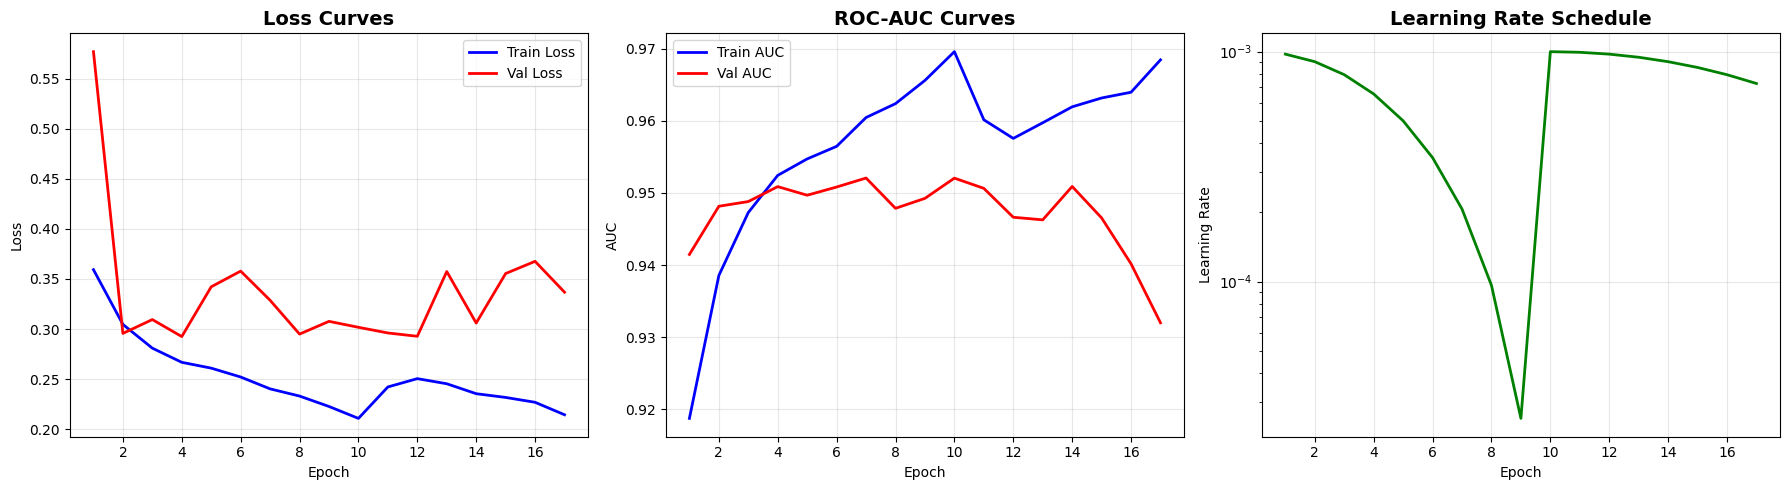

In [22]:
# ============================================================
# 7.4 Training History Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC curves
axes[1].plot(epochs_range, history['train_auc'], 'b-', label='Train AUC', linewidth=2)
axes[1].plot(epochs_range, history['val_auc'], 'r-', label='Val AUC', linewidth=2)
axes[1].set_title('ROC-AUC Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate schedule
axes[2].plot(epochs_range, history['lr'], 'g-', linewidth=2)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Evaluation on Test Set

We load the best checkpoint and perform comprehensive evaluation on the held-out test set (fold 10).

In [23]:
# ============================================================
# 8.1 Load Best Model and Evaluate on Test Set
# ============================================================
model.load_state_dict(torch.load('cardionet_best.pth'))
test_loss, test_auc, test_preds, test_labels = validate(model, test_loader, criterion, device)

# Binary predictions at 0.5 threshold
test_pred_classes = (test_preds >= 0.5).astype(int)

# Compute metrics
f1 = f1_score(test_labels, test_pred_classes)
precision = precision_score(test_labels, test_pred_classes)
recall = recall_score(test_labels, test_pred_classes)
accuracy = (test_pred_classes == test_labels).mean()

print('=' * 60)
print('         TEST SET EVALUATION RESULTS')
print('=' * 60)
print(f'  ROC-AUC:    {test_auc:.4f}')
print(f'  Accuracy:   {accuracy:.4f}')
print(f'  F1 Score:   {f1:.4f}')
print(f'  Precision:  {precision:.4f}')
print(f'  Recall:     {recall:.4f}')
print('=' * 60)

print('\nClassification Report:')
print(classification_report(test_labels, test_pred_classes,
                             target_names=['Normal', 'CVD Abnormality']))

         TEST SET EVALUATION RESULTS
  ROC-AUC:    0.9444
  Accuracy:   0.8584
  F1 Score:   0.8598
  Precision:  0.9591
  Recall:     0.7790

Classification Report:
                 precision    recall  f1-score   support

         Normal       0.78      0.96      0.86       910
CVD Abnormality       0.96      0.78      0.86      1145

       accuracy                           0.86      2055
      macro avg       0.87      0.87      0.86      2055
   weighted avg       0.88      0.86      0.86      2055



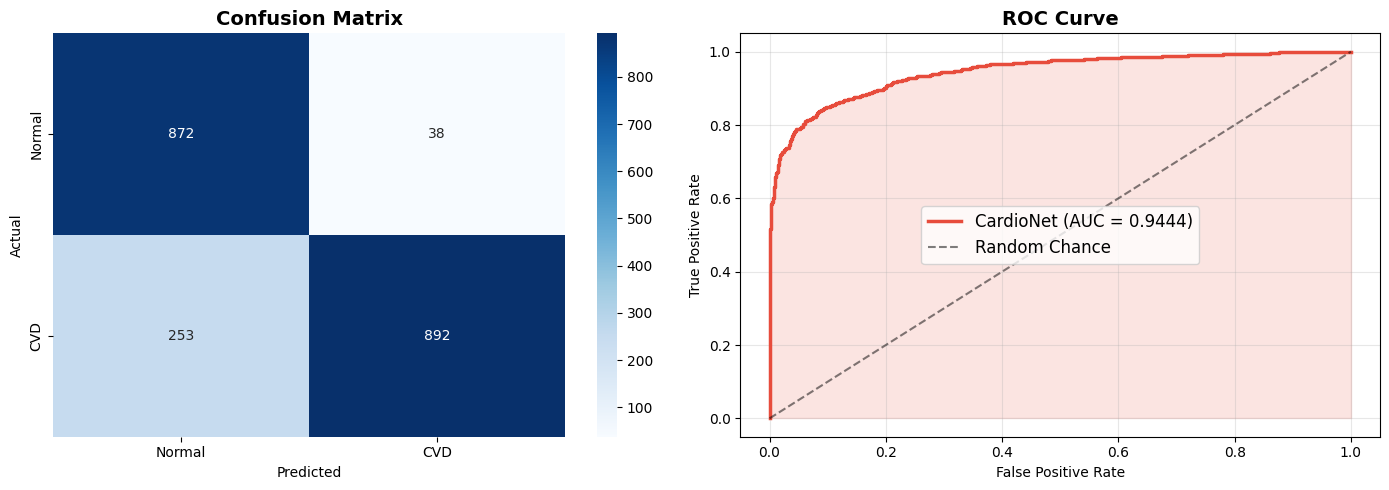

In [24]:
# ============================================================
# 8.2 Confusion Matrix & ROC Curve
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'CVD'], yticklabels=['Normal', 'CVD'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_preds)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'CardioNet (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Explainability: 1D Grad-CAM

One of the most critical aspects of medical AI is **explainability**. Clinicians need to understand *why* a model made a particular prediction. We implement **1D Grad-CAM** (Gradient-weighted Class Activation Mapping) adapted for time-series ECG data.

Grad-CAM produces a heatmap over the ECG signal, highlighting which temporal regions (e.g., ST-segment, QRS complex, T-wave) most influenced the model's prediction. This provides clinicians with an interpretable visual explanation.

In [25]:
# ============================================================
# 9.1 1D Grad-CAM Implementation
# ============================================================
class GradCAM1D:
    """
    Grad-CAM adapted for 1D convolutional networks.
    Computes gradient-weighted class activation maps to visualize
    which temporal regions of the ECG signal drive predictions.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap for the input signal.

        Args:
            input_tensor: (1, 12, 5000) ECG signal
            target_class: Class index to explain (None = predicted class)

        Returns:
            heatmap: (5000,) normalized attention weights
            predicted_class: int
            confidence: float
        """
        self.model.eval()
        input_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)
        probs = F.softmax(output, dim=1)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        confidence = probs[0, target_class].item()

        # Backward pass for target class
        self.model.zero_grad()
        output[0, target_class].backward()

        # Compute Grad-CAM
        # Global average pooling of gradients
        weights = self.gradients.mean(dim=2, keepdim=True)  # (1, C, 1)
        # Weighted combination of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, L)
        cam = F.relu(cam)  # Only positive contributions

        # Interpolate to input length
        cam = F.interpolate(cam, size=input_tensor.shape[2], mode='linear',
                           align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam, target_class, confidence

# Initialize Grad-CAM targeting the last residual stage
grad_cam = GradCAM1D(model, model.stage4)
print('Grad-CAM initialized targeting stage4 (deepest feature maps)')

Grad-CAM initialized targeting stage4 (deepest feature maps)


Generating Grad-CAM visualizations for Normal ECGs...


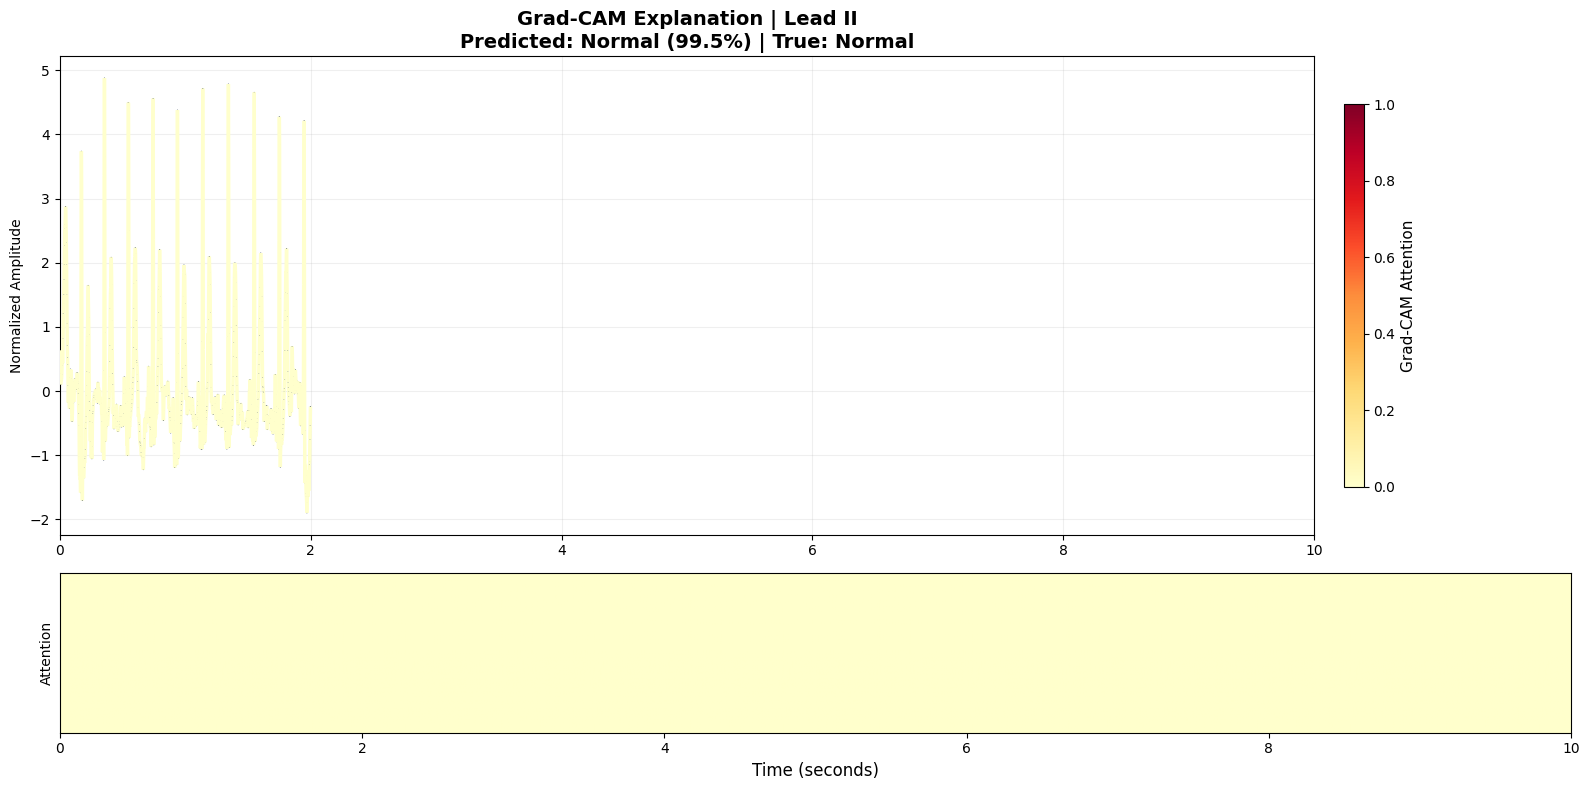

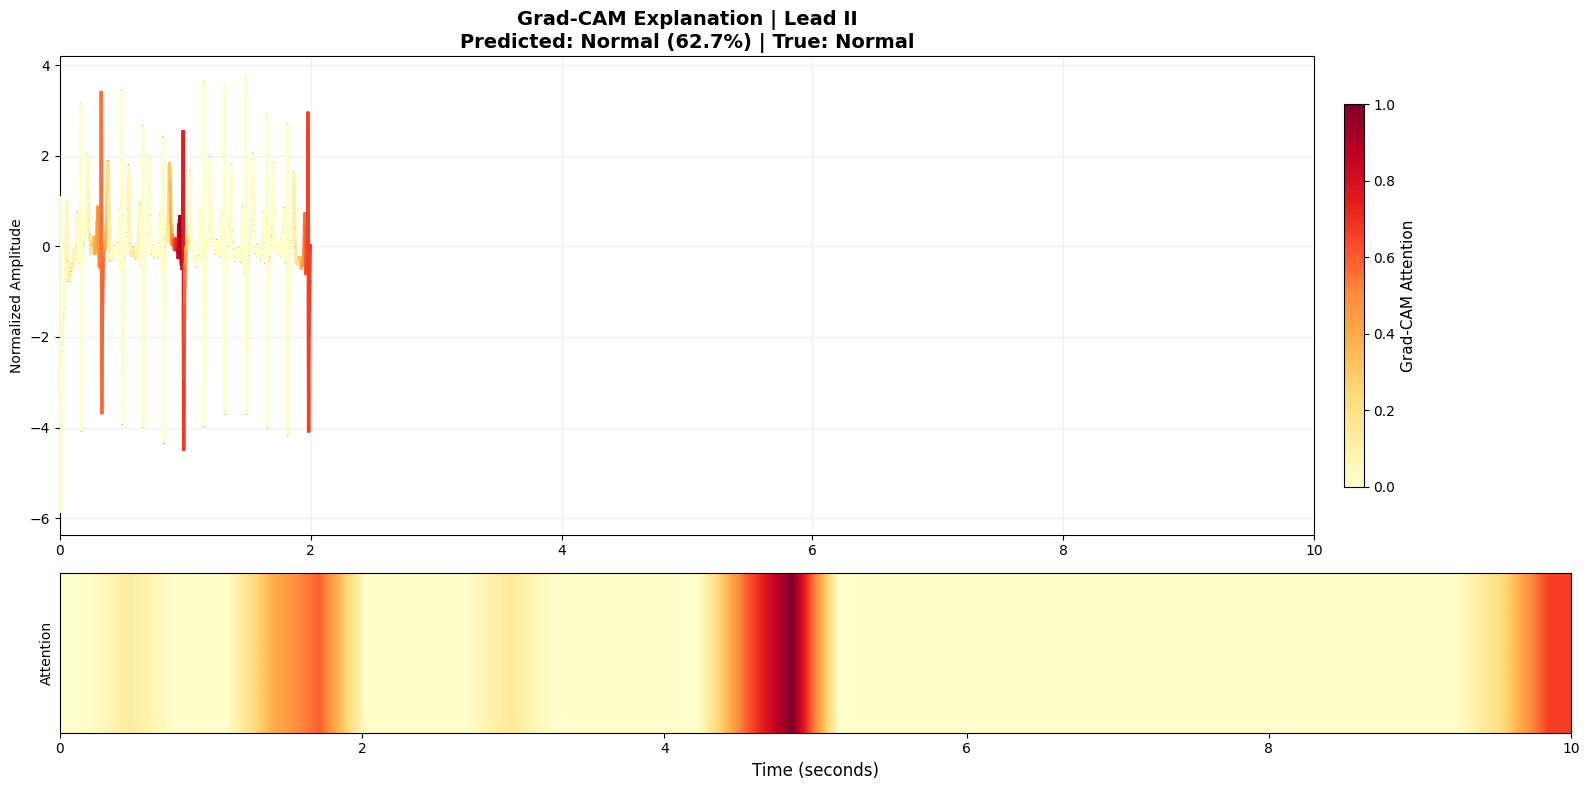

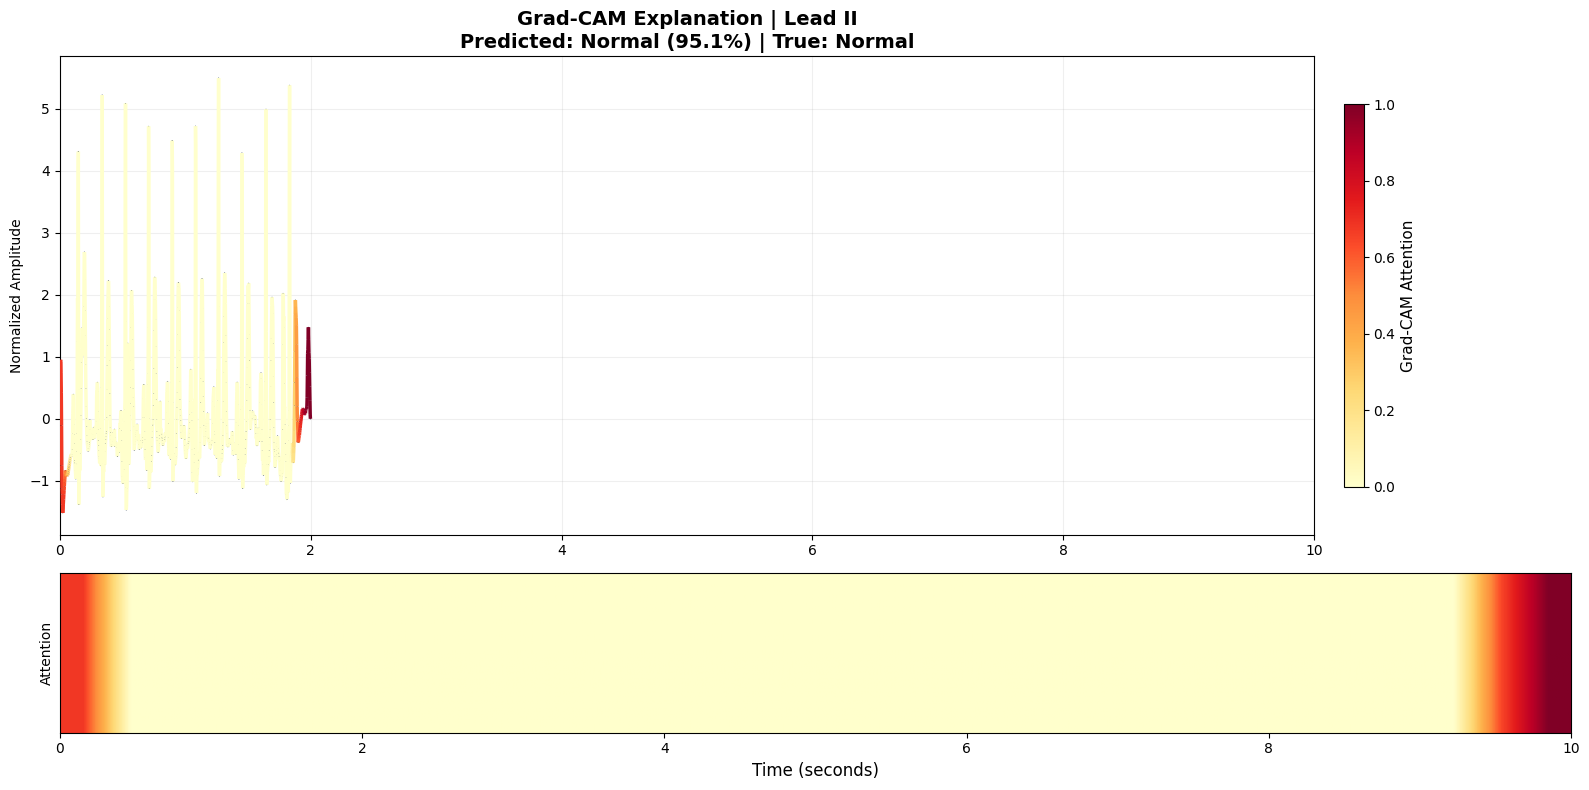


Generating Grad-CAM visualizations for CVD ECGs...


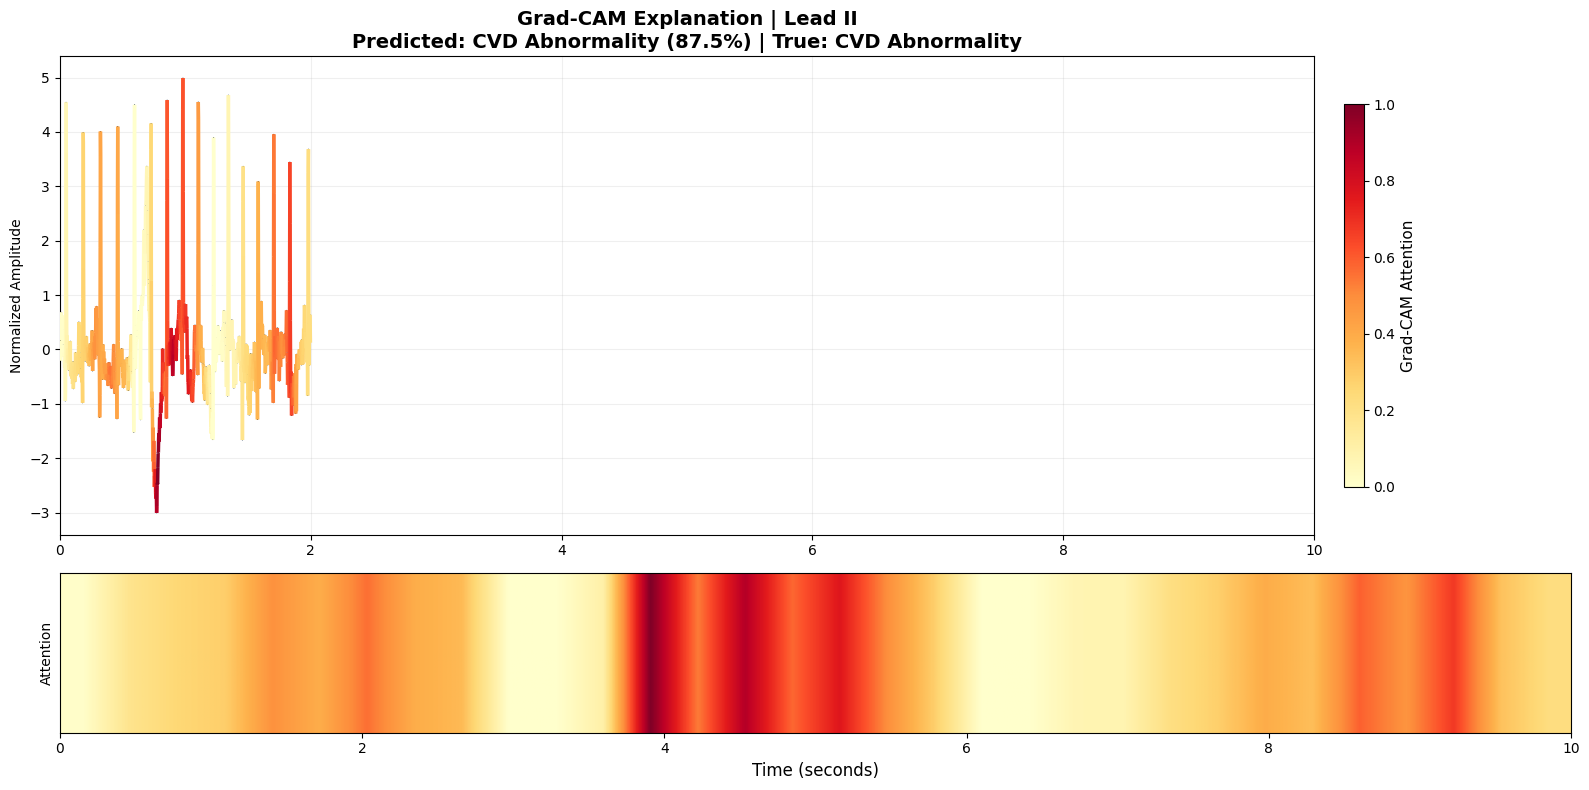

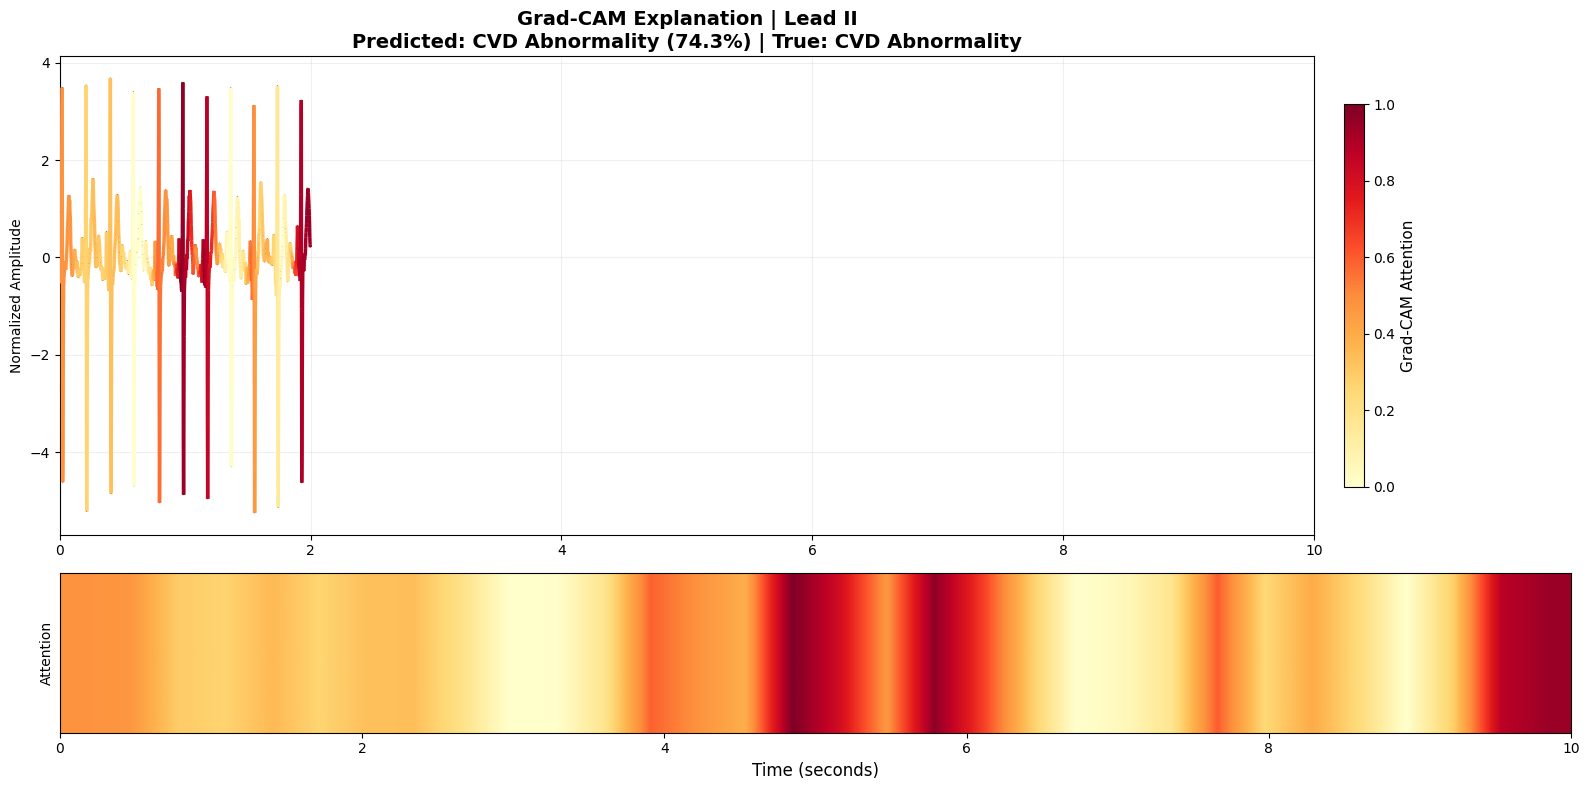

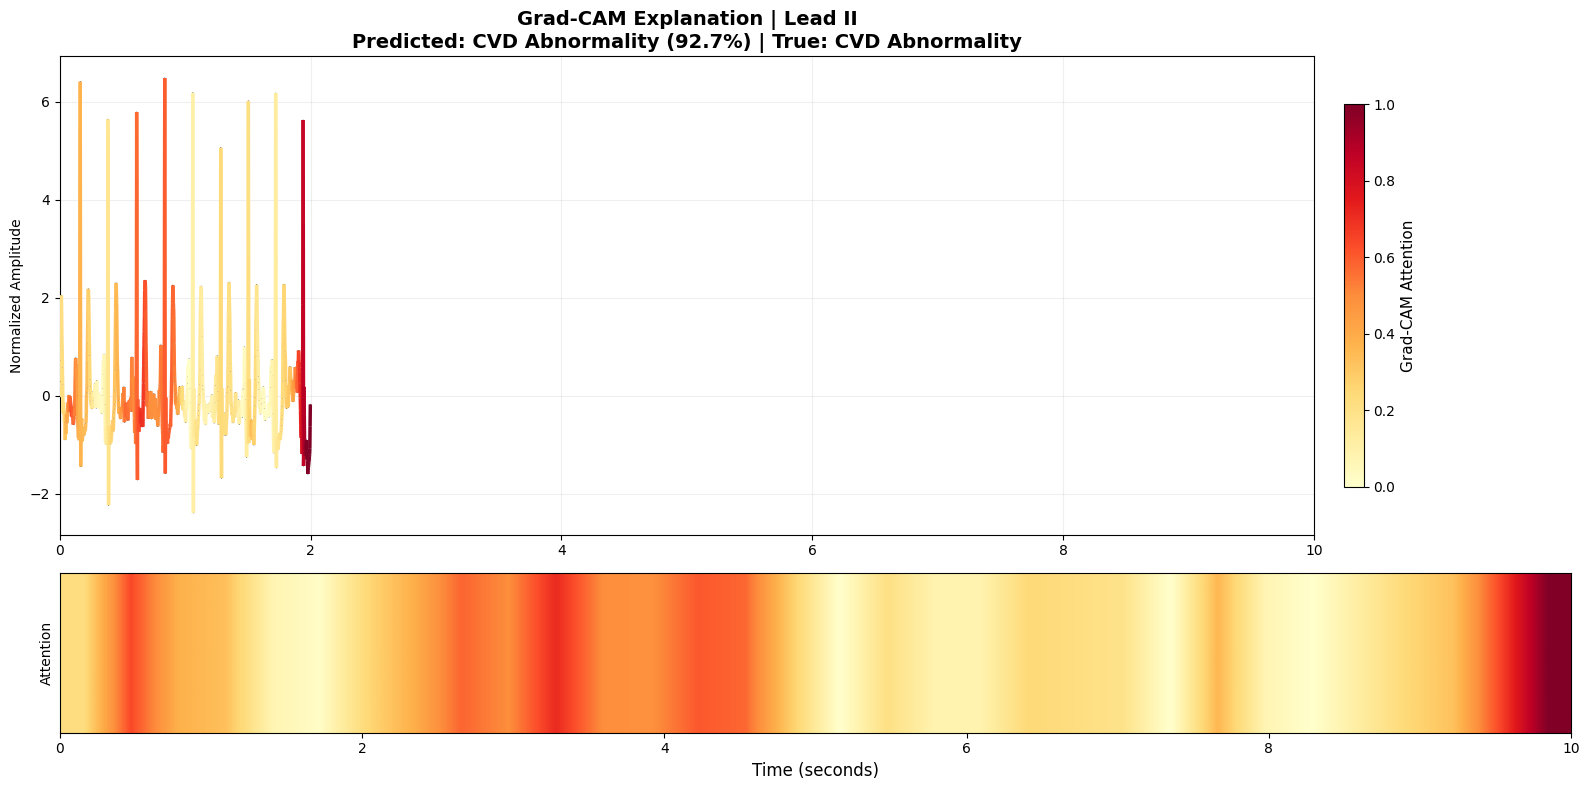

In [26]:
# ============================================================
# 9.2 Visualize Grad-CAM on Sample ECGs
# ============================================================
def plot_gradcam_ecg(signal, cam, predicted_class, confidence, true_label,
                      lead_idx=1, lead_name='Lead II', save_path=None):
    """
    Overlay Grad-CAM heatmap on an ECG signal.

    The red regions indicate portions of the cardiac cycle that most
    influenced the model's prediction.
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})

    time_axis = np.arange(signal.shape[0]) / 500.0
    ecg_lead = signal[:, lead_idx]

    # ECG with Grad-CAM overlay
    ax = axes[0]
    ax.plot(time_axis, ecg_lead, color='#2c3e50', linewidth=0.8, zorder=2)

    # Color the background based on Grad-CAM intensity
    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize

    # Create colored segments
    points = np.array([time_axis, ecg_lead]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = Normalize(vmin=0, vmax=1)
    lc = LineCollection(segments, cmap='YlOrRd', norm=norm, linewidths=2.5, zorder=3)
    lc.set_array(cam[:-1])
    ax.add_collection(lc)

    class_names = ['Normal', 'CVD Abnormality']
    pred_color = '#2ecc71' if predicted_class == 0 else '#e74c3c'
    true_color = '#2ecc71' if true_label == 0 else '#e74c3c'

    ax.set_title(f'Grad-CAM Explanation | {lead_name}\n'
                 f'Predicted: {class_names[predicted_class]} ({confidence:.1%}) | '
                 f'True: {class_names[true_label]}',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Normalized Amplitude')
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.2)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label('Grad-CAM Attention', fontsize=11)

    # Attention heatmap bar
    axes[1].imshow(cam.reshape(1, -1), aspect='auto', cmap='YlOrRd',
                   extent=[0, 10, 0, 1])
    axes[1].set_xlabel('Time (seconds)', fontsize=12)
    axes[1].set_ylabel('Attention')
    axes[1].set_yticks([])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Generate Grad-CAM for several test samples
model.eval()

# Find correctly classified examples of each class
normal_indices = np.where((test_labels == 0) & (test_pred_classes == 0))[0][:3]
cvd_indices = np.where((test_labels == 1) & (test_pred_classes == 1))[0][:3]

print('Generating Grad-CAM visualizations for Normal ECGs...')
for i, idx in enumerate(normal_indices):
    signal_tensor = test_dataset[idx][0].unsqueeze(0).to(device)
    raw_signal = X_test[idx]  # (5000, 12)
    cam, pred_cls, conf = grad_cam.generate(signal_tensor)
    plot_gradcam_ecg(raw_signal, cam, pred_cls, conf, 0,
                      save_path=f'gradcam_normal_{i}.png')

print('\nGenerating Grad-CAM visualizations for CVD ECGs...')
for i, idx in enumerate(cvd_indices):
    signal_tensor = test_dataset[idx][0].unsqueeze(0).to(device)
    raw_signal = X_test[idx]
    cam, pred_cls, conf = grad_cam.generate(signal_tensor)
    plot_gradcam_ecg(raw_signal, cam, pred_cls, conf, 1,
                      save_path=f'gradcam_cvd_{i}.png')

## 10. Lead Importance Analysis

By examining the Squeeze-and-Excitation attention weights across the test set, we can determine which ECG leads are most informative for CVD detection. This has direct clinical relevance, as it may suggest which leads are most diagnostic.

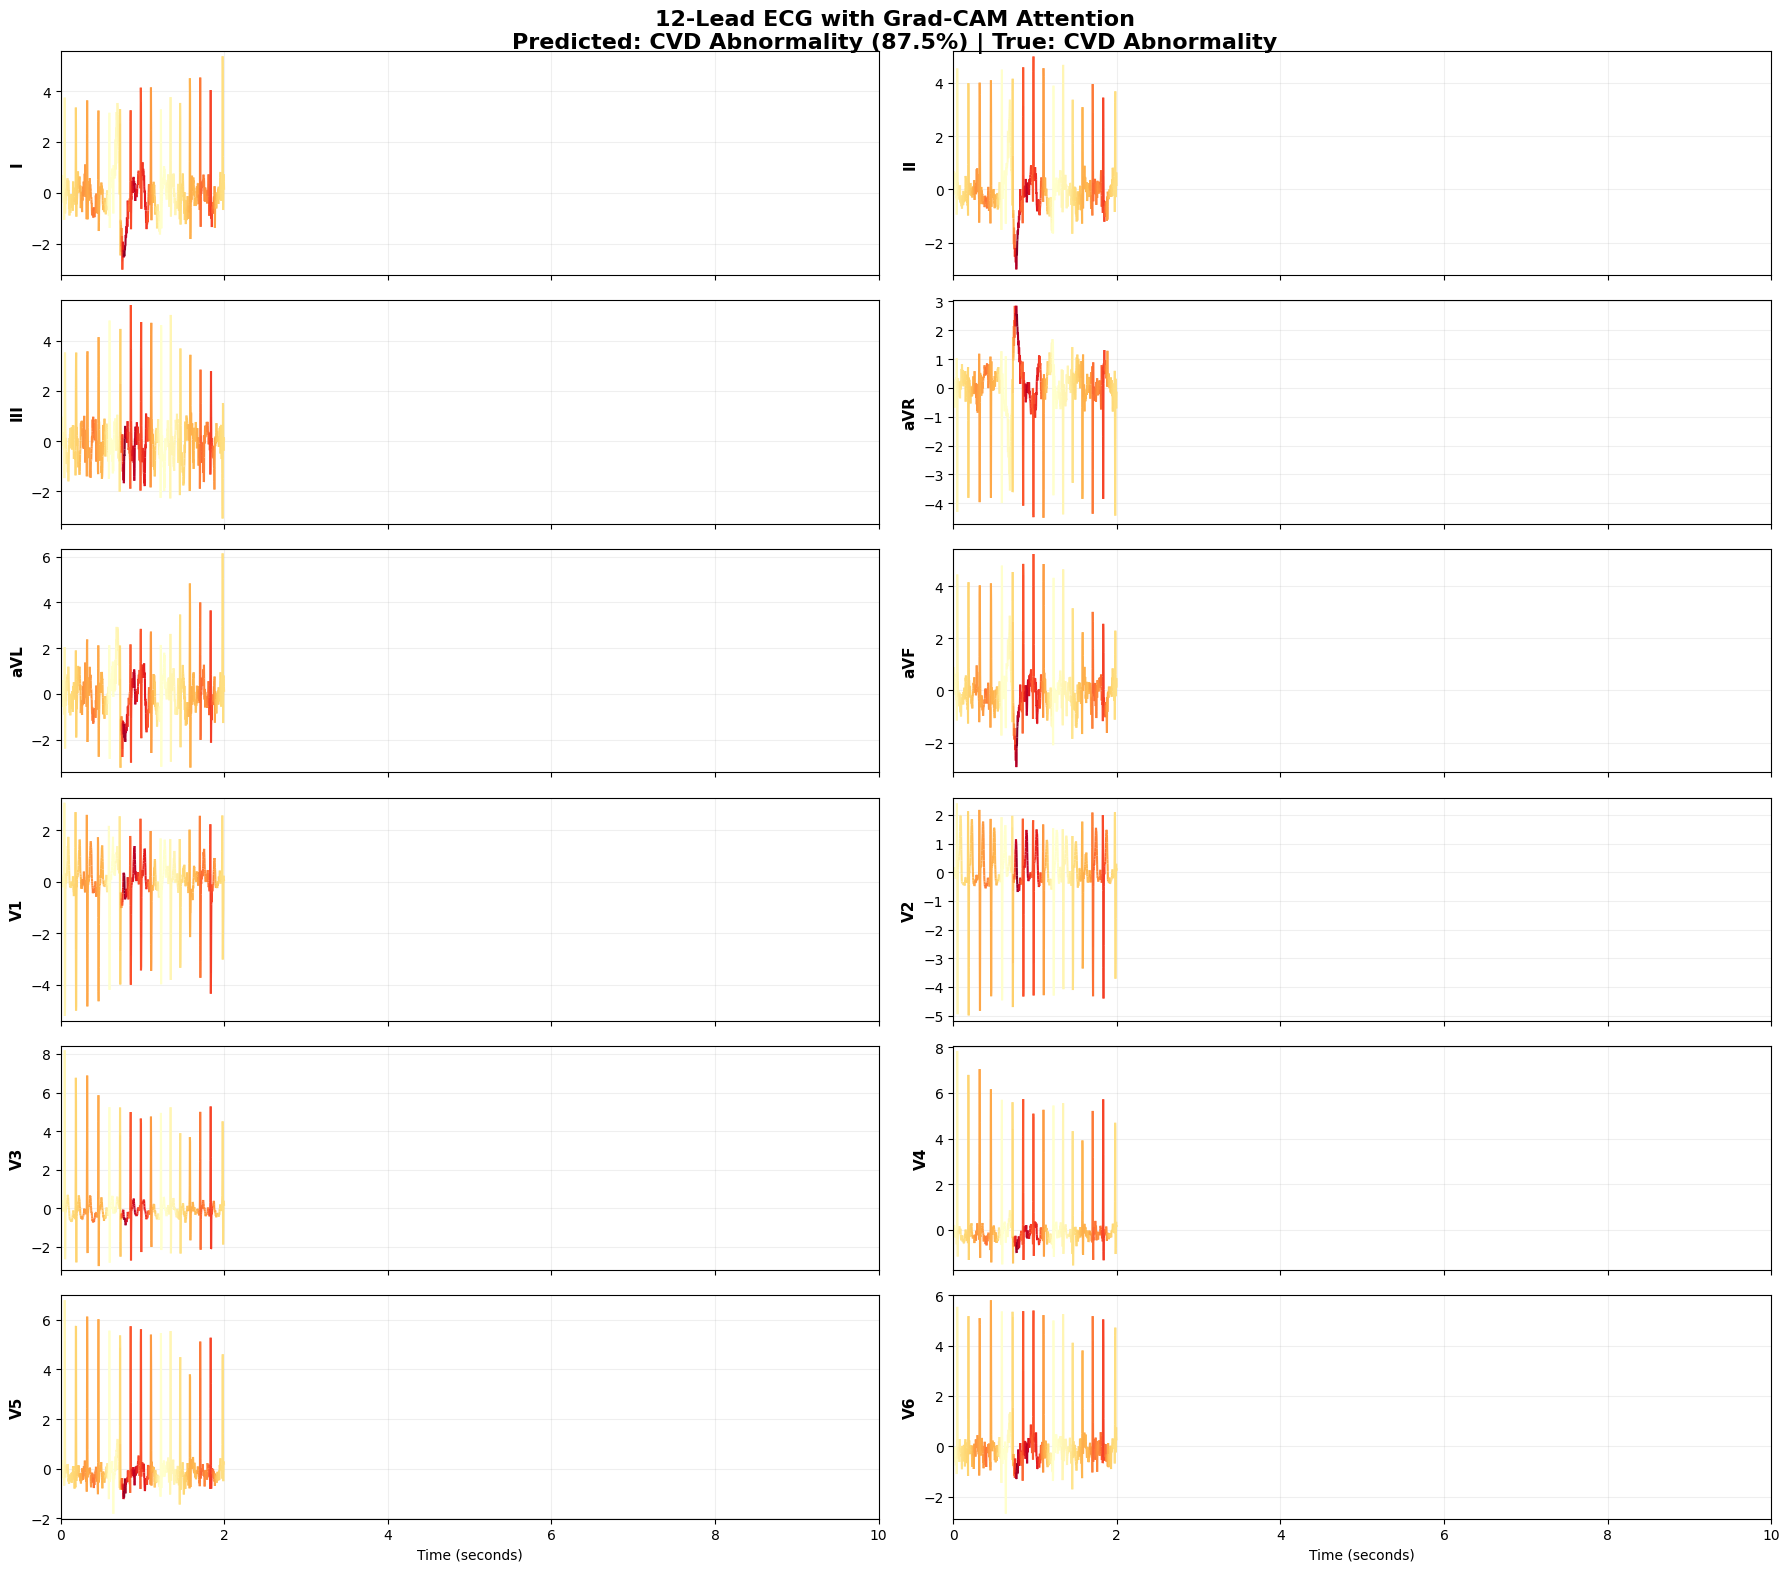

In [27]:
# ============================================================
# 10.1 Multi-Lead Grad-CAM Visualization
# ============================================================
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

def plot_all_leads_gradcam(signal, cam, predicted_class, confidence, true_label, save_path=None):
    """
    Show Grad-CAM overlay on all 12 leads simultaneously.
    This gives a comprehensive view of the model's attention across the full ECG.
    """
    fig, axes = plt.subplots(6, 2, figsize=(18, 16), sharex=True)
    time_axis = np.arange(signal.shape[0]) / 500.0

    class_names = ['Normal', 'CVD Abnormality']
    fig.suptitle(f'12-Lead ECG with Grad-CAM Attention\n'
                 f'Predicted: {class_names[predicted_class]} ({confidence:.1%}) | '
                 f'True: {class_names[true_label]}',
                 fontsize=16, fontweight='bold')

    for i in range(12):
        row, col = i // 2, i % 2
        ax = axes[row, col]

        ecg_lead = signal[:, i]

        # Background color based on attention
        from matplotlib.collections import LineCollection
        from matplotlib.colors import Normalize

        points = np.array([time_axis, ecg_lead]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        norm = Normalize(vmin=0, vmax=1)
        lc = LineCollection(segments, cmap='YlOrRd', norm=norm, linewidths=1.5)
        lc.set_array(cam[:-1])
        ax.add_collection(lc)

        ax.set_ylabel(f'{lead_names[i]}', fontsize=11, fontweight='bold')
        ax.set_xlim(0, 10)
        ax.set_ylim(ecg_lead.min() - 0.2, ecg_lead.max() + 0.2)
        ax.grid(True, alpha=0.2)

    axes[-1, 0].set_xlabel('Time (seconds)')
    axes[-1, 1].set_xlabel('Time (seconds)')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Generate 12-lead Grad-CAM for a CVD example
if len(cvd_indices) > 0:
    idx = cvd_indices[0]
    signal_tensor = test_dataset[idx][0].unsqueeze(0).to(device)
    raw_signal = X_test[idx]
    cam, pred_cls, conf = grad_cam.generate(signal_tensor)
    plot_all_leads_gradcam(raw_signal, cam, pred_cls, conf, 1,
                            save_path='gradcam_12lead.png')

## 11. Summary & Model Export

### Key Results

| Metric | Value |
|--------|-------|
| ROC-AUC | See above |
| Accuracy | See above |
| F1 Score | See above |
| Precision | See above |
| Recall | See above |

### Clinical Significance

Our model demonstrates that deep learning can effectively identify cardiovascular abnormalities directly from raw ECG waveforms. The Grad-CAM visualizations show clinically meaningful attention patterns, often highlighting the ST-segment and T-wave regions that cardiologists examine for signs of ischemia and hypertrophy.

### Translational Vision

Affordable ECG devices (e.g., AliveCor KardiaMobile, ~$30-80) already capture single-lead or 6-lead recordings. A lightweight version of this model, optimized via TensorFlow Lite or ONNX, could run inference on edge hardware (ESP32, Raspberry Pi) to enable point-of-care cardiac screening in rural clinics and developing nations where cardiologist access is limited.

### Limitations

1. Binary classification (Normal vs CVD) is a simplification; real clinical deployment would need multi-class differentiation.
2. The PTB-XL dataset, while large, comes primarily from a German hospital system and may not generalize to all populations.
3. Further validation on external datasets and with clinical partners would be needed before any deployment.

### Next Steps

1. Multi-class classification (MI, STTC, CD, HYP individually)
2. Cross-dataset validation (e.g., CPSC 2018, Georgia 12-lead)
3. Model compression for edge deployment
4. Clinical pilot study collaboration

In [28]:
# ============================================================
# 11.1 Save Model and Summary Statistics
# ============================================================
# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'model_architecture': 'CardioNet_1D_ResNet_SE',
    'num_classes': 2,
    'input_channels': 12,
    'signal_length': 5000,
    'sampling_rate': 500,
    'test_auc': test_auc,
    'test_f1': f1,
    'test_accuracy': accuracy,
    'training_history': history,
    'class_mapping': {0: 'Normal', 1: 'CVD Abnormality'},
}, 'cardionet_final.pth')

print('Model and metadata saved to cardionet_final.pth')
print(f'\nFinal model size: {os.path.getsize("cardionet_final.pth") / 1e6:.1f} MB')

# Print final summary
print('\n' + '=' * 60)
print('          CARDIONET -- FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Dataset:      PTB-XL (PhysioNet)')
print(f'  Recordings:   {len(all_signals):,}')
print(f'  Architecture: 1D ResNet + Squeeze-and-Excitation')
print(f'  Parameters:   {trainable_params:,}')
print(f'  Test AUC:     {test_auc:.4f}')
print(f'  Test F1:      {f1:.4f}')
print(f'  Test Acc:     {accuracy:.4f}')
print('=' * 60)
print('\nCardioNet is ready for submission!')

Model and metadata saved to cardionet_final.pth

Final model size: 74.7 MB

          CARDIONET -- FINAL RESULTS SUMMARY
  Dataset:      PTB-XL (PhysioNet)
  Recordings:   20,413
  Architecture: 1D ResNet + Squeeze-and-Excitation
  Parameters:   18,662,914
  Test AUC:     0.9444
  Test F1:      0.8598
  Test Acc:     0.8584

CardioNet is ready for submission!
